In [1]:
from codes.bk_recovery import *
from codes.noisemodel import *
from codes.optimisation import *
from codes.codewords import *
import matplotlib.pyplot as plt
import numpy as np

γ=6.3e-06 | Global: SDP=1.000000, BK=1.000000 | Local: SDP=1.000000, BK=1.000000
γ=9.3e-06 | Global: SDP=1.000000, BK=1.000000 | Local: SDP=1.000000, BK=1.000000
γ=1.4e-05 | Global: SDP=1.000000, BK=1.000000 | Local: SDP=1.000000, BK=1.000000
γ=2.0e-05 | Global: SDP=1.000000, BK=1.000000 | Local: SDP=1.000000, BK=1.000000
γ=3.0e-05 | Global: SDP=1.000000, BK=0.999999 | Local: SDP=1.000000, BK=1.000000
γ=4.4e-05 | Global: SDP=0.999999, BK=0.999998 | Local: SDP=1.000000, BK=1.000000
γ=6.5e-05 | Global: SDP=0.999998, BK=0.999996 | Local: SDP=1.000000, BK=1.000000
γ=9.5e-05 | Global: SDP=0.999995, BK=0.999991 | Local: SDP=1.000000, BK=1.000000
γ=1.4e-04 | Global: SDP=0.999989, BK=0.999981 | Local: SDP=0.999999, BK=0.999999
γ=2.1e-04 | Global: SDP=0.999977, BK=0.999959 | Local: SDP=0.999999, BK=0.999998
γ=3.0e-04 | Global: SDP=0.999951, BK=0.999912 | Local: SDP=0.999997, BK=0.999996
γ=4.5e-04 | Global: SDP=0.999893, BK=0.999811 | Local: SDP=0.999995, BK=0.999991
γ=6.6e-04 | Global: SDP=0.99

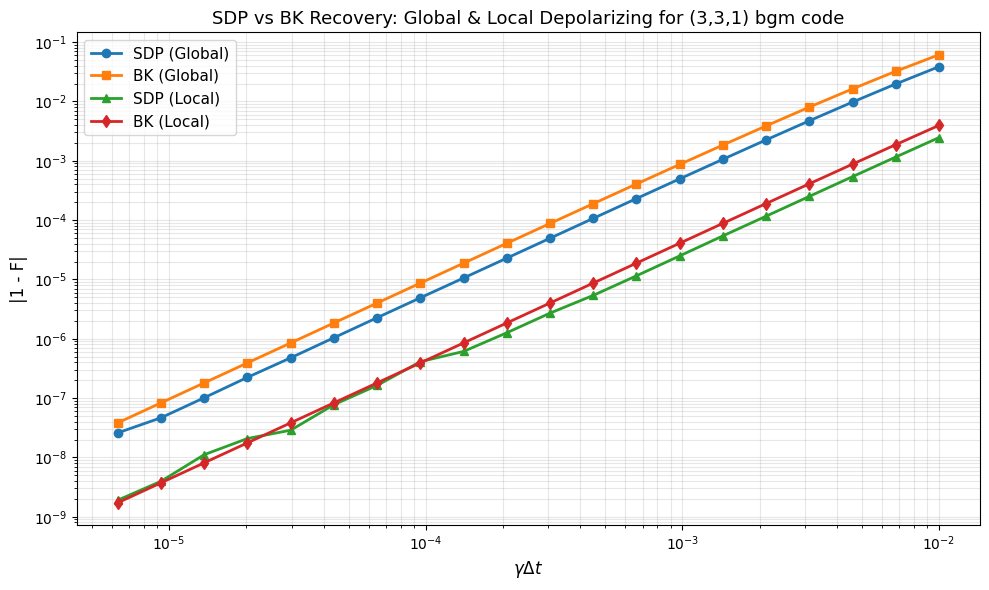

In [3]:
type_global = "global symmetric depolarizing"
type_local = "local symmetric depolarizing"
method_sdp = "choi"
method_bk = "choi"
dt = 1 

b=3
g=3
m=1
_, l0, l1 = bgmcode_piqs(b, g, m)
num_qubits = 2*b*m + g

gamma_values = np.logspace(-5.2, -2, 20)  # gamma from 1e-5 to 1e-2

# Storage for all four cases
fid_sdp_global_list = []
fid_bk_global_list = []
fid_sdp_local_list = []
fid_bk_local_list = []

for gamma in gamma_values:
    # Global depolarizing
    model_global = noisemodel(type_global, num_qubits, gamma, dt, method_sdp)
    fid_sdp_global = optimise(l0, l1, model_global)
    fid_bk_global = fidelity_bk_recovery(l0, l1, model_global, method_bk)
    
    # Local depolarizing
    model_local = noisemodel(type_local, num_qubits, gamma, dt, method_sdp)
    fid_sdp_local = optimise(l0, l1, model_local)
    fid_bk_local = fidelity_bk_recovery(l0, l1, model_local, method_bk)
    
    fid_sdp_global_list.append(fid_sdp_global)
    fid_bk_global_list.append(fid_bk_global)
    fid_sdp_local_list.append(fid_sdp_local)
    fid_bk_local_list.append(fid_bk_local)
    
    print(f"γ={gamma:.1e} | Global: SDP={fid_sdp_global:.6f}, BK={fid_bk_global:.6f} | Local: SDP={fid_sdp_local:.6f}, BK={fid_bk_local:.6f}")

# Convert to infidelities
infid_sdp_global = np.abs(1 - np.array(fid_sdp_global_list))
infid_bk_global = np.abs(1 - np.array(fid_bk_global_list))
infid_sdp_local = np.abs(1 - np.array(fid_sdp_local_list))
infid_bk_local = np.abs(1 - np.array(fid_bk_local_list))

# Log-log plot
p_vals = gamma_values * dt
plt.figure(figsize=(10, 6))
plt.loglog(p_vals, infid_sdp_global, 'o-', label='SDP (Global)', linewidth=2, markersize=6)
plt.loglog(p_vals, infid_bk_global, 's-', label='BK (Global)', linewidth=2, markersize=6)
plt.loglog(p_vals, infid_sdp_local, '^-', label='SDP (Local)', linewidth=2, markersize=6)
plt.loglog(p_vals, infid_bk_local, 'd-', label='BK (Local)', linewidth=2, markersize=6)
plt.xlabel('$\\gamma \\Delta t$', fontsize=12)
plt.ylabel('|1 - F|', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, which='both', alpha=0.3)
plt.title('SDP vs BK Recovery: Global & Local Depolarizing for (3,3,1) bgm code', fontsize=13)
plt.tight_layout()
plt.show()

<>:6: SyntaxWarning: invalid escape sequence '\D'
<>:6: SyntaxWarning: invalid escape sequence '\D'
/var/folders/ls/_bxfhnmd33vf9hs9yz_stz4c0000gq/T/ipykernel_41298/2073754192.py:6: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('$\\gamma \Delta t$ ', fontsize=12)


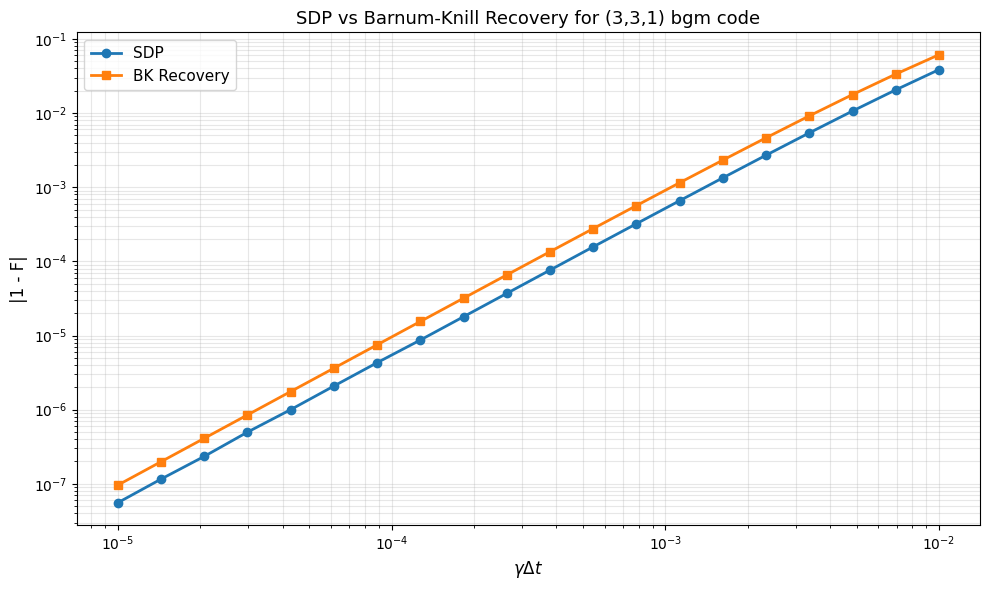

In [5]:
# Log-log plot
p_vals = gamma_values*dt
plt.figure(figsize=(10, 6))
plt.loglog(p_vals, infid_sdp, 'o-', label='SDP', linewidth=2, markersize=6)
plt.loglog(p_vals, infid_bk, 's-', label='BK Recovery', linewidth=2, markersize=6)
plt.xlabel('$\\gamma \Delta t$ ', fontsize=12)
plt.ylabel('|1 - F|', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, which='both', alpha=0.3)
plt.title('SDP vs Barnum-Knill Recovery for (3,3,1) bgm code', fontsize=13)
plt.tight_layout()
plt.show()

compute the recovery operators for the global depiolarising channel given in Gross's paper

In [40]:
import numpy as np
import qutip as qt

def spin_operators(N, p):
    j = N / 2
    dim = N + 1
    
    Jz = np.sqrt(p)* np.diag([j - m for m in range(dim)])
    
    Jp = np.zeros((dim, dim))
    Jm = np.zeros((dim, dim))
    
    for m in range(dim - 1):
        M = j - m
        coeff = np.sqrt(j*(j+1) - M*(M-1))
        Jm[m+1, m] = coeff
        Jp[m, m+1] = coeff
    
    Jx = np.sqrt(p)* 0.5 * (Jp + Jm)
    Jy = np.sqrt(p)*-0.5j * (Jp - Jm)
    I = (1-(j*(j+1)*p)/2)* np.eye(dim)
    E = list(map(qt.Qobj, [Jx, Jy, Jz, I]))
    return E


In [92]:
b=g=3
m=1
p=1e-4
l0,l1,N = bgmcode_kets_in_top_block(b, g, m, return_qutip=1)
rho = 0.5 * (l0*l0.dag() + l1*l1.dag())
E = spin_operators(N, p)
rho_prime = 0
for e in E: 
    rho_prime += e * rho * e.dag()
bk = bk_recovery_kraus(E, l0,l1)  
fidelity_bk_recovery(l0, l1, E)

1.0000015314062571

In [93]:
sum = 0 
for r in bk: 
    sum += r.dag() * r
sum

Quantum object: dims=[[10], [10]], shape=(10, 10), type='oper', dtype=Dense, isherm=True
Qobj data =
[[1.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 1.38167255e-13 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.25000000e-01 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 3.30718914e-01
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 8.75000000e-01 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  3.30718914e-01 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 1.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 5.57498492e-13]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  1.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 1.00000000e+00 0.00000000e+00 0.000

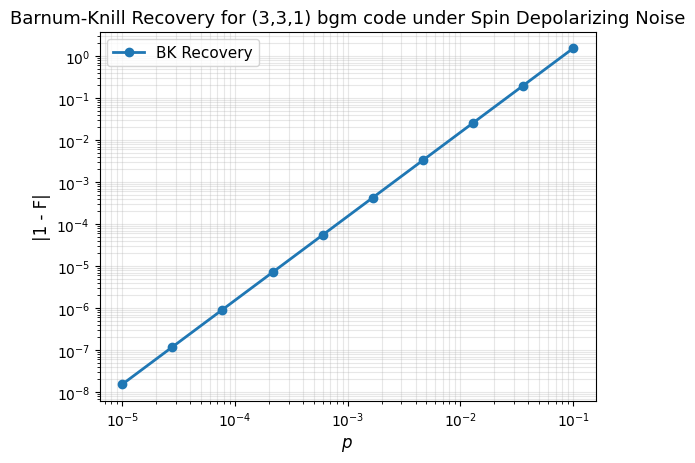

In [65]:
p = np.logspace(-5, -1, 10)
f_bk = []
for pi in p:
    E = spin_operators(N, pi)
    f_bk.append(fidelity_bk_recovery(l0, l1, E))
plt.loglog(p, np.abs(1 - np.array(f_bk)), 'o-', label='BK Recovery', linewidth=2, markersize=6)
plt.xlabel('$p$ ', fontsize=12)
plt.ylabel('|1 - F|', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, which='both', alpha=0.3)
plt.title('Barnum-Knill Recovery for (3,3,1) bgm code under Spin Depolarizing Noise', fontsize=13)    
plt.show()    

In [60]:
def compose_kraus(R_list, E_list):
    # Kraus for R∘E are { R_a E_b }
    return [Ra * Eb for Ra in R_list for Eb in E_list]

def restriction_choi_to_codespace(kraus_list, P):
    # compare induced channel on code subspace via sandwiching Kraus: K_i -> P K_i P
    Kc = [P * K * P for K in kraus_list]
    return kraus_to_choi(Kc)

def codespace_choi_distance(R_list, E_list, P):
    RE = compose_kraus(R_list, E_list)
    J_RE = restriction_choi_to_codespace(RE, P)
    # identity channel on codespace: Kraus = [P] (acts as identity within codespace)
    J_I = restriction_choi_to_codespace([P], P)
    return float((J_RE - J_I).norm())
